#                         **E Commerce dataset Analysis**

**Objective:** The goal of this project is to analyze an e-commerce dataset to understand customer behavior, sales patterns, delivery performance, and payment preferences. The analysis aims to generate actionable business insights that can help improve customer satisfaction and revenue.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

The dataset contains order-level information from an e-commerce platform.

Key Columns:

order_id: Unique order identifier

customer_id: Unique customer identifier

gender: Customer gender

age: Customer age

city: Customer city

product_category: Category of product ordered

payment_mode: Payment method used

order_amount: Total order value

delivery_days: Days taken to deliver the order

order_rating: Customer rating (1–5)

order_date: Date of order

The dataset includes both numeric and categorical variables and contains missing values, making it suitable for real-world analysis.

In [3]:
df=pd.read_csv("/content/ecommerce_orders_big.csv")
df

,order_id,customer_id,gender,age,city,product_category,payment_mode,order_amount,delivery_days,order_rating,order_date
0,1001,C0001,Male,29.0,Chennai,Grocery,UPI,45400.0,2.0,1.0,2024-01-01
1,1002,C0002,NaN,33.0,Delhi,Grocery,UPI,10600.0,1.0,3.0,2024-01-02
2,1003,C0003,Female,41.0,Chennai,Home Decor,NaN,46400.0,1.0,5.0,2024-01-03
3,1004,C0004,Female,36.0,Chennai,Home Decor,Credit Card,39800.0,8.0,3.0,2024-01-04
4,1005,C0005,Male,25.0,Delhi,Home Decor,Credit Card,33900.0,2.0,3.0,2024-01-05
...,...,...,...,...,...,...,...,...,...,...,...
995,1996,C0996,Male,38.0,Delhi,Beauty,Debit Card,30300.0,2.0,NaN,2026-09-22
996,1997,C0997,NaN,26.0,Delhi,Electronics,NaN,57700.0,NaN,3.0,2026-09-23
997,1998,C0998,Male,45.0,Delhi,Beauty,Debit Card,43800.0,NaN,NaN,2026-09-24
998,1999,C0999,NaN,24.0,Delhi,Beauty,Debit Card,7000.0,3.0,5.0,2026-09-25


In [4]:
df.shape  # checks how many rows and columns are there in dataset

(1000, 11)

In [5]:
df.info()  # checked the basic information about the dataset like not null values ,data types and name of columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1000 non-null   int64  
 1   customer_id       1000 non-null   object 
 2   gender            900 non-null    object 
 3   age               984 non-null    float64
 4   city              1000 non-null   object 
 5   product_category  1000 non-null   object 
 6   payment_mode      791 non-null    object 
 7   order_amount      999 non-null    float64
 8   delivery_days     896 non-null    float64
 9   order_rating      834 non-null    float64
 10  order_date        1000 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 86.1+ KB


In [6]:
df.dtypes # checked datatypes of each column separately

,0
order_id,int64
customer_id,object
gender,object
age,float64
city,object
product_category,object
payment_mode,object
order_amount,float64
delivery_days,float64
order_rating,float64


In [7]:
df.head()  #checked first 5 rows of dataset

,order_id,customer_id,gender,age,city,product_category,payment_mode,order_amount,delivery_days,order_rating,order_date
0,1001,C0001,Male,29.0,Chennai,Grocery,UPI,45400.0,2.0,1.0,2024-01-01
1,1002,C0002,NaN,33.0,Delhi,Grocery,UPI,10600.0,1.0,3.0,2024-01-02
2,1003,C0003,Female,41.0,Chennai,Home Decor,NaN,46400.0,1.0,5.0,2024-01-03
3,1004,C0004,Female,36.0,Chennai,Home Decor,Credit Card,39800.0,8.0,3.0,2024-01-04
4,1005,C0005,Male,25.0,Delhi,Home Decor,Credit Card,33900.0,2.0,3.0,2024-01-05


In [8]:
df.tail()   #checked last 5 rows of dataset

,order_id,customer_id,gender,age,city,product_category,payment_mode,order_amount,delivery_days,order_rating,order_date
995,1996,C0996,Male,38.0,Delhi,Beauty,Debit Card,30300.0,2.0,NaN,2026-09-22
996,1997,C0997,NaN,26.0,Delhi,Electronics,NaN,57700.0,NaN,3.0,2026-09-23
997,1998,C0998,Male,45.0,Delhi,Beauty,Debit Card,43800.0,NaN,NaN,2026-09-24
998,1999,C0999,NaN,24.0,Delhi,Beauty,Debit Card,7000.0,3.0,5.0,2026-09-25
999,2000,C1000,Male,33.0,Bangalore,Beauty,NaN,46100.0,4.0,2.0,2026-09-26


#Data cleaning & Preprocessing



Steps performed:

Checked dataset shape, data types, and duplicates

Identified missing values column-wise

Applied appropriate imputation strategies:

Gender & payment_mode → Mode

Age → Median (robust to outliers)

Delivery_days → Mean (limited numeric range)

Order_rating → Mean (fixed 1–5 scale)

Dropped rows with missing order_amount due to its importance in revenue analysis

Converted order_date to datetime format

In [9]:
df.isnull().sum()    # checked the total number of null values for imputing

,0
order_id,0
customer_id,0
gender,100
age,16
city,0
product_category,0
payment_mode,209
order_amount,1
delivery_days,104
order_rating,166


In [10]:
df["gender"].unique()  # checked the unique values in gender column for treating the missing values in it

array(['Male', nan, 'Female'], dtype=object)

In [11]:
df["gender"].fillna(df["gender"].mode()[0],inplace=True)  # Treating missing values of gender column with mode method beacuse it is a categorical column so fillig the missing value with most frequent value
df.isnull().sum()

,0
order_id,0
customer_id,0
gender,0
age,16
city,0
product_category,0
payment_mode,209
order_amount,1
delivery_days,104
order_rating,166


treating the missing values of age column by median method beacuse Age may contain outliers, so median is a robust measure and prevents skewing the distribution.”

In [12]:
df["age"].fillna(df["age"].median(),inplace=True)

In [13]:
df.isnull().sum()

,0
order_id,0
customer_id,0
gender,0
age,0
city,0
product_category,0
payment_mode,209
order_amount,1
delivery_days,104
order_rating,166


In [14]:
df["payment_mode"].unique()  # checking unique values of payment_mode column

array(['UPI', nan, 'Credit Card', 'COD', 'Debit Card'], dtype=object)

Treating the missing values of payment_mode with mode beacuse it is an categorical column so mode methode is approppriate for imputing

In [15]:
df["payment_mode"].fillna(df["payment_mode"].mode()[0],inplace=True)
df.isnull().sum()

,0
order_id,0
customer_id,0
gender,0
age,0
city,0
product_category,0
payment_mode,0
order_amount,1
delivery_days,104
order_rating,166


In [16]:
df["delivery_days"].unique()  #checked the unique values of delivery_days column

array([ 2.,  1.,  8.,  5.,  4., nan,  7.,  3.,  6.])

Treated the missing values of delivery_days column by mean beacuse it is a Numeric column.it has Small, bounded values (1–8 days).it has No extreme outliers (no 100, 500 days etc.) it Represents an average delivery time, which makes business sense


In [17]:
df["delivery_days"].fillna(df["delivery_days"].mean(),inplace=True)
df.isnull().sum()

,0
order_id,0
customer_id,0
gender,0
age,0
city,0
product_category,0
payment_mode,0
order_amount,1
delivery_days,0
order_rating,166


droped the missing value from order_amount column beacuse it has only 1 missing value and droping that never make big difference to the dataset

In [18]:
df=df.dropna(subset=["order_amount"])
df.isnull().sum()

,0
order_id,0
customer_id,0
gender,0
age,0
city,0
product_category,0
payment_mode,0
order_amount,0
delivery_days,0
order_rating,166


In [19]:
df["order_rating"].unique()  #checked the unique values of order_rating column

array([ 1.,  3.,  5.,  2., nan,  4.])

Treated the missing values of order_rating column by mean beacuse it is a Numeric column.it has Small, bounded values .it has No extreme outliers. it Represents an average order rating, which makes business sense.

In [20]:
df["order_rating"].fillna(df["order_rating"].mean(),inplace=True)

In [21]:
df.isnull().sum()

,0
order_id,0
customer_id,0
gender,0
age,0
city,0
product_category,0
payment_mode,0
order_amount,0
delivery_days,0
order_rating,0


In [22]:
df["order_date"].dtype

dtype('O')

In [23]:
df["order_date"]=pd.to_datetime(df["order_date"])  # converting order_date to it's appropriate type which is datetime for better use of column and to extract months and years.

In [24]:
df.dtypes

,0
order_id,int64
customer_id,object
gender,object
age,float64
city,object
product_category,object
payment_mode,object
order_amount,float64
delivery_days,float64
order_rating,float64


# Feature Engineering

To enable time-based analysis, new features were created:

order_month: Extracted month from order_date

order_year: Extracted year from order_date

These features help identify trends and seasonality in orders and revenue.

In [25]:
df.duplicated().sum()  # checked if there are any duplicate value

np.int64(0)

In [26]:
df["order_months"]=df["order_date"].dt.month   #extracted the months from order_date

In [27]:
df.head()

,order_id,customer_id,gender,age,city,product_category,payment_mode,order_amount,delivery_days,order_rating,order_date,order_months
0,1001,C0001,Male,29.0,Chennai,Grocery,UPI,45400.0,2.0,1.0,2024-01-01,1
1,1002,C0002,Male,33.0,Delhi,Grocery,UPI,10600.0,1.0,3.0,2024-01-02,1
2,1003,C0003,Female,41.0,Chennai,Home Decor,COD,46400.0,1.0,5.0,2024-01-03,1
3,1004,C0004,Female,36.0,Chennai,Home Decor,Credit Card,39800.0,8.0,3.0,2024-01-04,1
4,1005,C0005,Male,25.0,Delhi,Home Decor,Credit Card,33900.0,2.0,3.0,2024-01-05,1


In [28]:
df["order_year"]=df["order_date"].dt.year   # Extracted the year from order_date
df.head()

,order_id,customer_id,gender,age,city,product_category,payment_mode,order_amount,delivery_days,order_rating,order_date,order_months,order_year
0,1001,C0001,Male,29.0,Chennai,Grocery,UPI,45400.0,2.0,1.0,2024-01-01,1,2024
1,1002,C0002,Male,33.0,Delhi,Grocery,UPI,10600.0,1.0,3.0,2024-01-02,1,2024
2,1003,C0003,Female,41.0,Chennai,Home Decor,COD,46400.0,1.0,5.0,2024-01-03,1,2024
3,1004,C0004,Female,36.0,Chennai,Home Decor,Credit Card,39800.0,8.0,3.0,2024-01-04,1,2024
4,1005,C0005,Male,25.0,Delhi,Home Decor,Credit Card,33900.0,2.0,3.0,2024-01-05,1,2024


# Exploratory Data Analysis (EDA)

### Gender-wise Average Order Amount Analysis

I grouped the dataset by **gender** and calculated the **mean order amount** to analyze purchasing behavior.

**Key Observations:**
- Female customers show a higher average order value (**₹31,224.66**) compared to male customers (**₹29,689.30**).
- This suggests that female customers may be contributing more to revenue per transaction.

**Business Insight:**
Targeted marketing strategies and personalized offers for female customers could further enhance overall revenue.


In [29]:
data=df.groupby("gender")["order_amount"]
data.mean()

,order_amount
gender,
Female,31224.657534
Male,29689.304813


### Gender-wise Average Age Analysis

The dataset was grouped by **gender**, and the average age was computed for each group.

**Observations:**
- Female customers have an average age of **38.18 years**
- Male customers have an average age of **38.36 years**
- The difference in average age is minimal, suggesting that age is not a distinguishing factor between genders in this dataset.

**Insight:**
Since the age distribution is similar across genders, differences observed in spending behavior are likely influenced by factors other than age.



In [30]:
data=df.groupby("gender")["age"]
data.mean()

,age
gender,
Female,38.180365
Male,38.356506


### Gender wise Product category and average order amount Analytics


* Female customer spends more on Grocery and Beauty  
*  Male customer spends more on Home decor
* Grocery is a high-value category in both male and female.



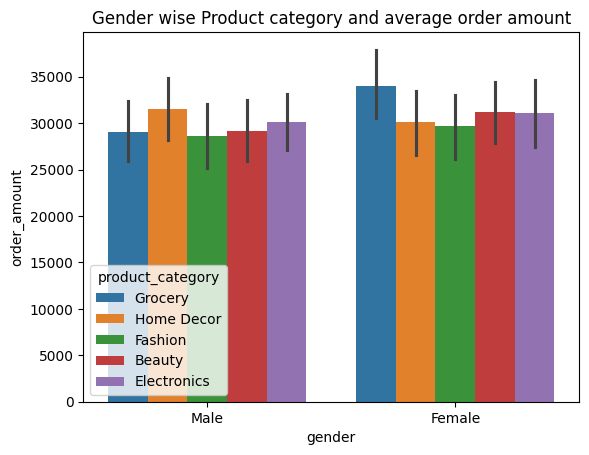

In [31]:
plt.figure()
sns.barplot(data=df,x="gender",y="order_amount",hue="product_category")
plt.title("Gender wise Product category and average order amount")
plt.show()

In [32]:
data=df.groupby(["gender","product_category"])["order_amount"]
data.mean()

gender  product_category
Female  Beauty              31228.235294
        Electronics         31053.684211
        Fashion             29722.500000
        Grocery             34023.529412
        Home Decor          30130.107527
Male    Beauty              29141.176471
        Electronics         30111.811024
        Fashion             28609.909910
        Grocery             29101.724138
        Home Decor          31500.952381
Name: order_amount, dtype: float64

### Gender wise Monthly orders Analytics
*  Female have highest order in 7th month which is 47.
* Male have highest order in 5th order which is 58.
* overall Male have higher orders than Female.

### Insight
female has more average order amount with less order Which means Female are buying expencive items more than male.




In [33]:
data=df.groupby(["gender","order_months"])["order_id"]
data.count()

gender  order_months
Female  1               42
        2               35
        3               42
        4               40
        5               35
        6               38
        7               47
        8               37
        9               40
        10              30
        11              23
        12              29
Male    1               51
        2               50
        3               51
        4               50
        5               58
        6               52
        7               45
        8               56
        9               46
        10              32
        11              37
        12              33
Name: order_id, dtype: int64

### Gender wise Yearly orders Analytics
* Orders are decreasing year wise, 2026 has less orders by both male and female.
* Male has higher orders in every month.
* highest orders are in 2025 by male which are 212.

In [34]:
data=df.groupby(["gender","order_year"])["order_id"]
data.count()

gender  order_year
Female  2024          166
        2025          153
        2026          119
Male    2024          199
        2025          212
        2026          150
Name: order_id, dtype: int64

### Total Order amount Product Category


*   Electronics Generates Higher Revenue which is 6774300
*   Fashion Generates Lesser Revenue Compare to all Products which is 5553500

By Targeting Electronics marketing Strartgies we can even make Higher Revenue.



In [35]:
data=df.groupby("product_category")["order_amount"]
data.sum()

,order_amount
product_category,
Beauty,5626800.0
Electronics,6774300.0
Fashion,5553500.0
Grocery,6267800.0
Home Decor,6109700.0


### Total Orders by Product category

* Electronics has higher purchases which is 222.
* Beauty has lesser purchases which is 187.

In [36]:
data=df.groupby("product_category")["order_id"]
data.count()

,order_id
product_category,
Beauty,187
Electronics,222
Fashion,191
Grocery,201
Home Decor,198


### Total Order by city

* Chennai has the highest number of Orders which are 221.
* Mumbai has very less order which are 172.

In [37]:
data=df.groupby("city")["order_id"]
data.count()

,order_id
city,
Bangalore,198
Chennai,221
Delhi,199
Mumbai,172
Pune,209


### City wise Total Order by year

* Chennai has very High Orders in year 2024 and 2025 but in 2026 the amount of order is gone down badly which is 54.
* Delhi have higher orders in year 2025.

In [38]:
data=df.groupby(["city","order_year"])["order_id"]
data.count()

city       order_year
Bangalore  2024          61
           2025          74
           2026          63
Chennai    2024          85
           2025          82
           2026          54
Delhi      2024          67
           2025          83
           2026          49
Mumbai     2024          70
           2025          58
           2026          44
Pune       2024          82
           2025          68
           2026          59
Name: order_id, dtype: int64

### Creating Subset of Chennai

we have choosen channai for City wise analysis because Chennai have Higher orders Compare to all cities.

In [39]:
# Creating a subset of the dataset containing only Chennai city data for city-level analysis
chennai_df = df[df['city'] == 'Chennai']

### Gender wise Order in perticular category in Chennai



*  Electonics and Grocery both have high revenue in city Chennai by both male and female.
* Male have Comparatively higher Orders than Female.  



In [40]:
data=chennai_df.groupby(["gender","product_category"])["order_id"]
data.count()

gender  product_category
Female  Beauty              20
        Electronics         22
        Fashion             15
        Grocery             21
        Home Decor          12
Male    Beauty              21
        Electronics         32
        Fashion             22
        Grocery             30
        Home Decor          26
Name: order_id, dtype: int64

### Gender wise Total order amount in Chennai

* Female customer spends more on Electronics and Beauty.
* Male Customer Spends more on Home Decor.
* Home decor is the category which have higher order_amount in both male and female.

In [41]:
data=chennai_df.groupby(["gender","product_category"])["order_amount"]
data.mean()

gender  product_category
Female  Beauty              32055.000000
        Electronics         35427.272727
        Fashion             29160.000000
        Grocery             40157.142857
        Home Decor          32058.333333
Male    Beauty              28071.428571
        Electronics         30703.125000
        Fashion             30686.363636
        Grocery             29420.000000
        Home Decor          33269.230769
Name: order_amount, dtype: float64

### Total Order amount by Payment mode

- UPI transactions have the highest average order value.
- Debit Card transactions show the lowest average order amount.
- The difference across payment methods is relatively small, indicating consistent spending behavior regardless of payment type.

**Business Insight:**
Since UPI shows slightly higher average transaction value, businesses can encourage digital payment adoption through cashback offers or incentives.

In [42]:
data=df.groupby("payment_mode")["order_amount"]
data.mean()

,order_amount
payment_mode,
COD,30431.264916
Credit Card,30030.582524
Debit Card,29741.000000
UPI,31304.022989


### Order Distribution by Product Category and Payment Mode


- **Cash on Delivery (COD)** is the most preferred payment method across all product categories.
- In categories like Electronics, Fashion, and Home Decor, COD significantly dominates over digital payment options.
- Credit Card and Debit Card usage remains moderate across categories.
- UPI usage is comparatively lower than COD in all product segments.

**Insight:**

Customers still show a strong preference for COD across product types, indicating trust or convenience factors associated with pay-on-delivery.

**Business Implication:**

While digital payments are growing, businesses should maintain efficient COD operations. However, incentives such as cashback offers on UPI or Credit Card payments could help shift users toward digital modes and reduce COD-related operational risks.

In [43]:
data=df.groupby(["product_category","payment_mode"])["order_id"]
data.count()

product_category  payment_mode
Beauty            COD             72
                  Credit Card     45
                  Debit Card      39
                  UPI             31
Electronics       COD             94
                  Credit Card     47
                  Debit Card      42
                  UPI             39
Fashion           COD             85
                  Credit Card     32
                  Debit Card      41
                  UPI             33
Grocery           COD             83
                  Credit Card     40
                  Debit Card      42
                  UPI             36
Home Decor        COD             85
                  Credit Card     42
                  Debit Card      36
                  UPI             35
Name: order_id, dtype: int64

In [44]:
data=df.groupby(["delivery_days","order_rating"])["order_id"]
data.count()

delivery_days  order_rating
1.000000       1.000000        15
               2.000000        17
               2.960384        14
               3.000000        19
               4.000000        13
               5.000000        20
2.000000       1.000000        25
               2.000000        22
               2.960384        20
               3.000000        18
               4.000000        20
               5.000000        23
3.000000       1.000000        16
               2.000000        17
               2.960384        14
               3.000000        18
               4.000000        23
               5.000000        16
4.000000       1.000000        26
               2.000000        21
               2.960384        20
               3.000000        21
               4.000000        17
               5.000000        12
4.482143       1.000000        16
               2.000000        19
               2.960384        18
               3.000000        19
               4.000000        14
               5.000000        18
5.000000       1.000000        19
               2.000000        21
               2.960384        26
               3.000000        25
               4.000000        17
               5.000000        15
6.000000       1.000000        16
               2.000000        20
               2.960384        23
               3.000000        19
               4.000000        18
               5.000000        15
7.000000       1.000000        17
               2.000000        18
               2.960384        21
               3.000000        21
               4.000000        19
               5.000000        21
8.000000       1.000000        14
               2.000000        24
               2.960384        10
               3.000000        15
               4.000000        15
               5.000000        19
Name: order_id, dtype: int64

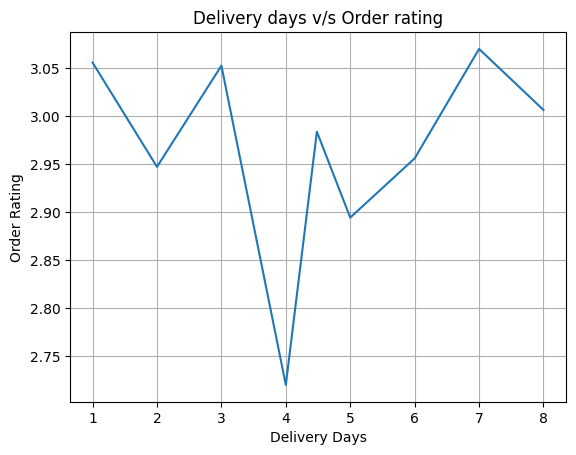

In [45]:
plt.figure()
df.groupby("delivery_days")["order_rating"].mean().plot(kind="line")
plt.xlabel("Delivery Days")
plt.ylabel("Order Rating")
plt.title("Delivery days v/s Order rating")
plt.grid()
plt.show()

# Visualization

### Distribution of Order Amount

The histogram above visualizes the distribution of order amounts across all transactions.

**Observations:**

- Order amounts are spread across a wide range, approximately from ₹1,000 to ₹60,000.
- The distribution appears relatively uniform without extreme concentration in a single range.
- There is no strong evidence of extreme outliers.

**Insight:**

The wide distribution indicates that the platform serves both low-value and high-value customers.
Since the order amounts are not heavily skewed, the mean is a reasonable measure of central tendency for further analysis.

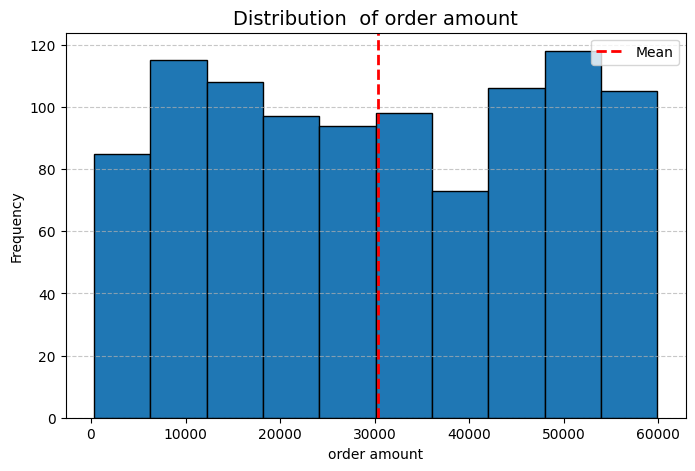

In [46]:
plt.figure(figsize=(8,5))
plt.hist(df["order_amount"],bins=10,edgecolor="black")
plt.title("Distribution  of order amount",fontsize=14)
plt.xlabel("order amount")
plt.ylabel("Frequency")

plt.axvline(df["order_amount"].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Distribution of Delivery Days

The histogram illustrates the distribution of delivery times (in days) across all orders.

**Observations:**

- Most deliveries are completed between 3 to 6 days.
- The peak frequency appears around 4 days, indicating this is the most common delivery time.
- Very few deliveries exceed 7–8 days.
- There is no extreme skewness in the distribution.

**Insight:**

The majority of orders are delivered within a reasonable timeframe (under 6 days), suggesting operational efficiency.
Maintaining delivery within the 3–5 day range could enhance customer satisfaction and retention.

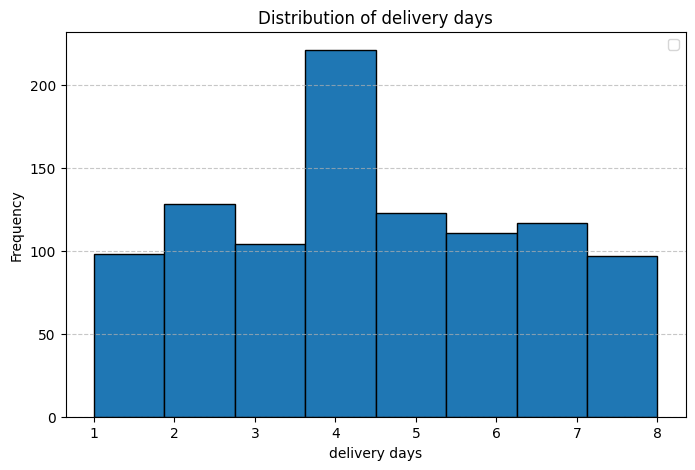

In [47]:
plt.figure(figsize=(8,5))
plt.hist(df["delivery_days"],bins=8,edgecolor="black")

plt.title("Distribution of delivery days")
plt.xlabel("delivery days")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [48]:
df["order_rating"] = df["order_rating"].round().astype(int)

### Order Rating Distribution

The count plot illustrates the distribution of customer ratings across all orders.

**Observations:**

- Rating 3 has the highest frequency, indicating most customers had an average experience.
- Lower ratings (1 and 2) are also considerable in number.
- High satisfaction ratings (4 and 5) are comparatively fewer.

**Insight:**

The dominance of rating 3 suggests that customer experience is moderate rather than excellent.
The presence of a significant number of low ratings (1 and 2) indicates potential service or product quality issues.

Improving operational efficiency, product quality, or delivery speed may help shift ratings toward 4 and 5.

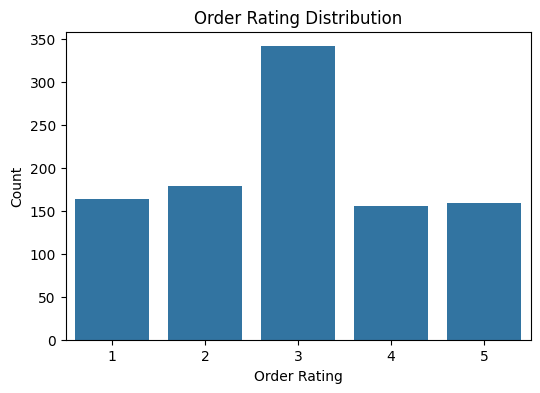

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(x="order_rating", data=df)

plt.title("Order Rating Distribution")
plt.xlabel("Order Rating")
plt.ylabel("Count")

plt.show()

### Distribution of Customer Age

The histogram illustrates the age distribution of customers using the platform.

**Observations:**

- Customers range approximately between 18 and 60 years.
- The distribution appears relatively uniform across age groups.
- There is no strong skew toward a particular age bracket.
- The mean and median age are closely aligned, indicating a balanced demographic spread.

**Insight:**

The platform caters to a wide age demographic rather than a niche group.
Marketing strategies can therefore be designed to target multiple age segments, with potential personalization based on purchasing behavior across different age groups.

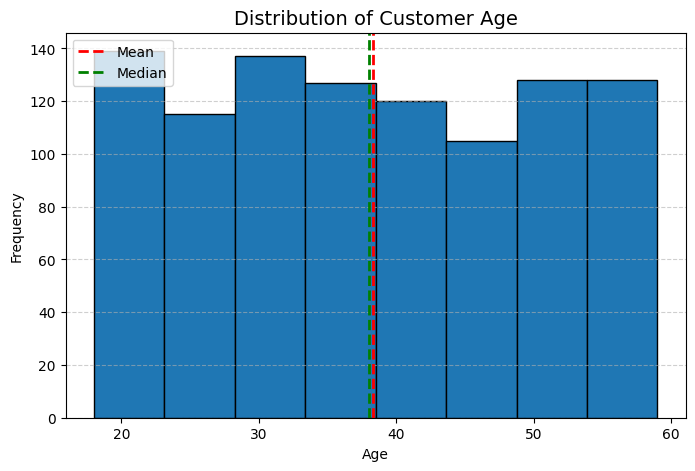

In [50]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=8, edgecolor='black')

plt.title("Distribution of Customer Age", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Frequency")


plt.axvline(df["age"].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df["age"].median(), color='green', linestyle='dashed', linewidth=2, label='Median')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

### Orders by City
The bar graph illustrates the Orders by City.

**Observations:**


*  Chennai has highest orders which are above 200.
*  Mumbai has lowest orders among all city.




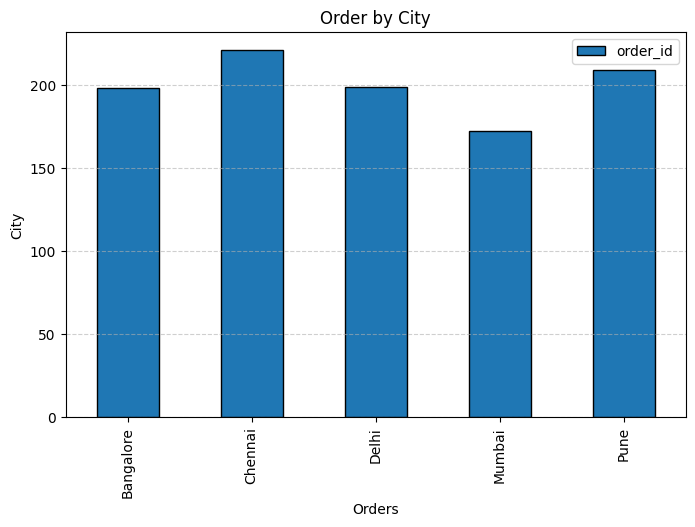

In [51]:
plt.figure(figsize=(8,5))
df.groupby("city")["order_id"].count().plot(kind="bar",edgecolor="black")
plt.title("Order by City")
plt.xlabel("Orders")
plt.ylabel("City")
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.legend()
plt.show()

### Average Order Amount by Product Category

This bar chart shows the average order amount for each product category.

**Observations:**

- Grocery has the highest average order amount.
- Home Decor and Electronics also have relatively high average order values.
- Fashion has the lowest average order amount among the categories.
- The average order values across categories are quite similar, with only small differences.

**Conclusion:**

Customers tend to spend slightly more on Grocery and Home Decor products compared to other categories.
However, overall spending is fairly balanced across all product categories.

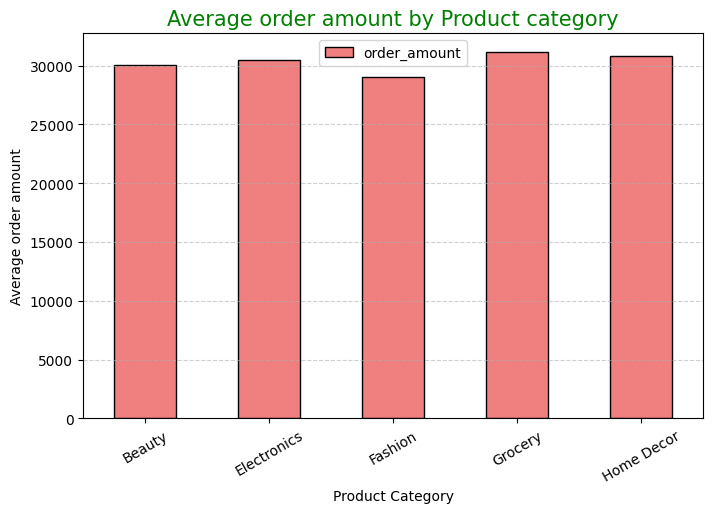

In [52]:
plt.figure(figsize=(8,5))
df.groupby("product_category")["order_amount"].mean().plot(kind="bar",edgecolor="black",color="lightcoral")
plt.title("Average order amount by Product category",fontsize=15,color="Green")
plt.xlabel("Product Category")
plt.ylabel("Average order amount")
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.xticks(rotation=30)
plt.legend()
plt.show()

### Total Revenue by City

This bar chart shows the total revenue generated from different cities.

**Observations:**

- Chennai generates the highest revenue among all the cities.
- Pune and Delhi also contribute a high amount of revenue.
- Bangalore and Mumbai generate slightly lower revenue compared to other cities.
- Overall, the revenue difference between cities is not very large.

**Conclusion:**

All cities contribute significantly to the total revenue. However, Chennai appears to be the strongest market and may have higher customer demand compared to other cities.

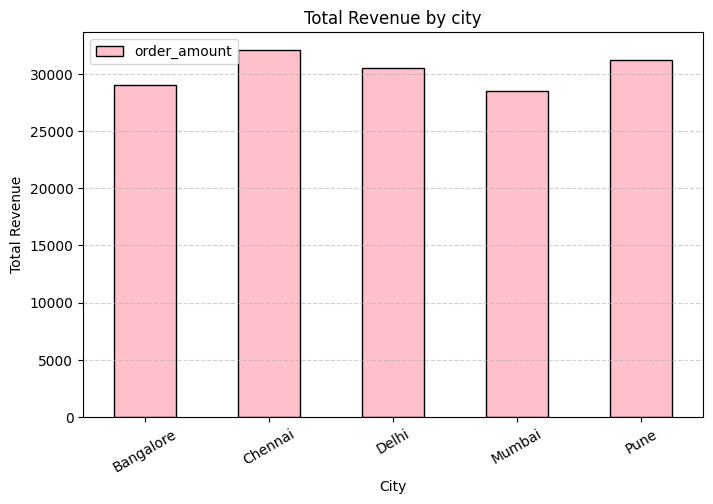

In [53]:
plt.figure(figsize=(8,5))
df.groupby("city")["order_amount"].mean().plot(kind="bar",edgecolor="black",color="pink")
plt.title("Total Revenue by city")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.xticks(rotation=30)
plt.legend()
plt.show()

### Order Count by Payment Mode

This bar chart shows the number of orders placed using different payment methods.

**Observations:**

- Cash on Delivery (COD) has the highest number of orders.
- Credit Card and Debit Card have a moderate number of orders.
- UPI has the lowest order count among the payment methods.

**Conclusion:**

Most customers prefer Cash on Delivery compared to digital payment options.
This may indicate that customers feel more comfortable paying after receiving the product.

Businesses can encourage digital payments like UPI or cards by offering discounts or cashback to reduce dependency on COD.

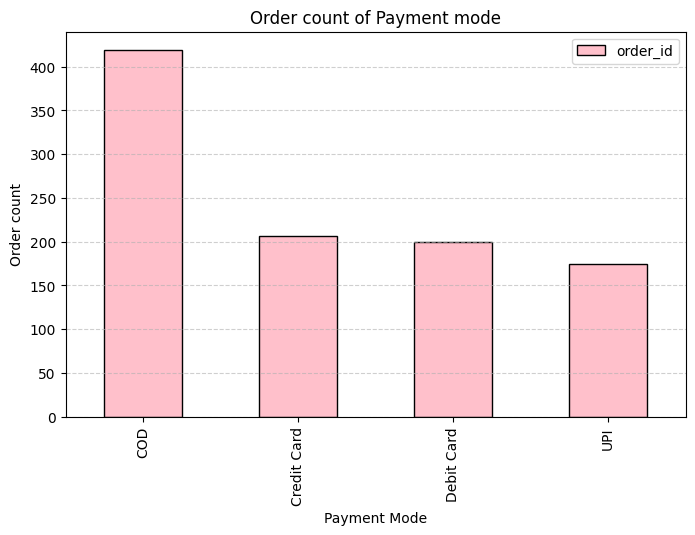

In [54]:
plt.figure(figsize=(8,5))
df.groupby("payment_mode")["order_id"].count().plot(kind="bar",color="pink",edgecolor="black")
plt.title("Order count of Payment mode")
plt.xlabel("Payment Mode")
plt.ylabel("Order count")
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.legend()
plt.show()

 ### Average Order Amount by Gender

This bar chart shows the average order amount for male and female customers.

**Observations:**

- Female customers have a slightly higher average order amount compared to male customers.
- Male customers have a slightly lower average order value.

**Conclusion:**

This suggests that female customers tend to spend a little more per order than male customers. However, the difference between the two groups is not very large.

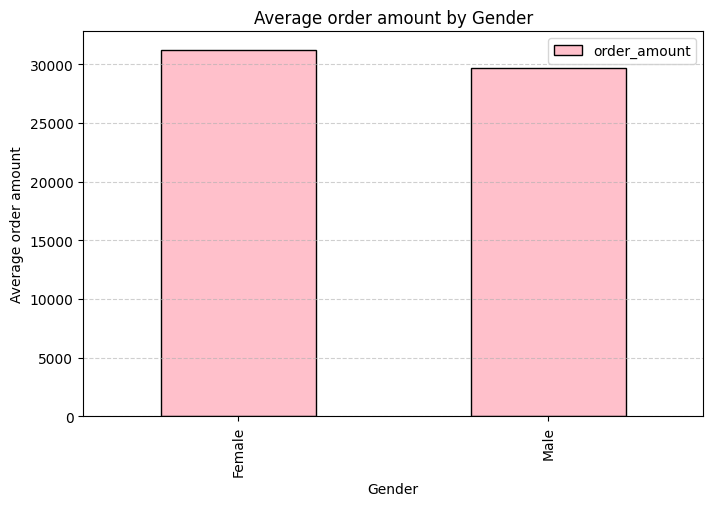

In [55]:
plt.figure(figsize=(8,5))
df.groupby("gender")["order_amount"].mean().plot(kind="bar",color="pink",edgecolor="black")
plt.title("Average order amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Average order amount")
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.legend()
plt.show()

### Average Rating by Product Category

This bar chart shows the average customer rating for each product category.

**Observations:**

- Home Decor has the highest average rating among all categories.
- Fashion also has a relatively high average rating.
- Beauty, Electronics, and Grocery have slightly lower but similar ratings.

**Conclusion:**

Overall, the ratings across all product categories are close to each other, indicating that customer satisfaction is fairly consistent across the platform. However, Home Decor and Fashion products appear to have slightly better customer feedback.

Businesses can further investigate categories with slightly lower ratings to understand customer concerns and improve product quality or service.

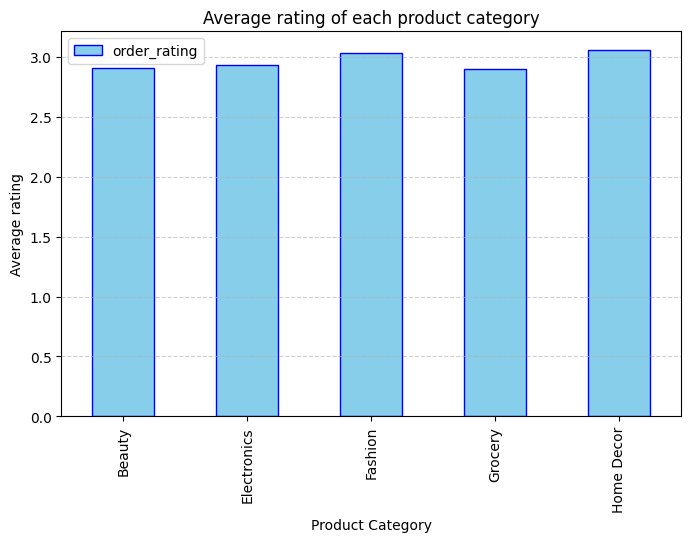

In [56]:
plt.figure(figsize=(8,5),edgecolor="blue")
df.groupby("product_category")["order_rating"].mean().plot(kind="bar",edgecolor="blue",color="skyblue")
plt.title("Average rating of each product category")
plt.xlabel("Product Category")
plt.ylabel("Average rating")
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.legend()
plt.show()

In [69]:
df["order_rating"].unique()

array([1, 3, 5, 2, 4])

In [70]:
df["order_rating"] = df["order_rating"].round()

###Delivery Days vs. Order Rating
**Observations**

* Most orders are delivered within 4 days.

* The most frequent occurrence in the data is a 3-star rating at the 4-day delivery mark, totaling 78 instances.

* Ratings of 1 and 2 also show their highest frequency at the 4-day mark, with 42 and 40 instances respectively.

* 5-star ratings remain consistent across the timeline, ranging between 15 and 30 occurrences regardless of delivery duration.

**Insights**

Improving the customer experience during the 4-day delivery window is the most effective way to reduce the high volume of average ratings.

Product quality appears to sustain high satisfaction for many customers even when delivery takes up to 8 days.

High delivery volumes at the 4-day mark correlate with a rise in lower ratings, suggesting a need for better quality control during busy periods.

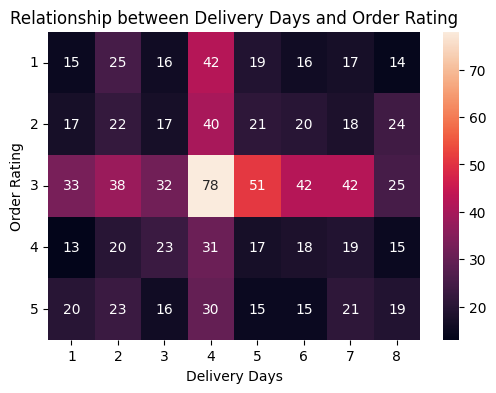

In [72]:
df["order_rating"] = df["order_rating"].astype(int)
df["delivery_days"] = df["delivery_days"].astype(int)

heatmap_data = pd.crosstab(df["order_rating"], df["delivery_days"])

plt.figure(figsize=(6,4))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="rocket",
    fmt="d",
    cbar=True
)

plt.title("Relationship between Delivery Days and Order Rating")
plt.xlabel("Delivery Days")
plt.ylabel("Order Rating")

plt.yticks(rotation=0)

plt.show()

### Order Amount Spread per Delivery Day
**Observations**

* Order amounts consistently range from 0 to 60,000 regardless of the delivery duration.

* The median order value stays stable around 30,000 across all delivery days from 1 to 8.

* The middle 50% of all orders typically fall between the 15,000 and 45,000 price range.

* There is no significant difference in the distribution of spend between fast (1-day) and slow (8-day) deliveries.

**Insights**

High-value purchases are not being prioritized for faster shipping, as the spread of order amounts is identical across all delivery speeds.

Customers show a willingness to wait up to 8 days even for expensive orders exceeding 50,000.

Since the 4-day delivery window has the highest volume of average ratings, focusing on high-value orders within that window could prevent financial dissatisfaction.

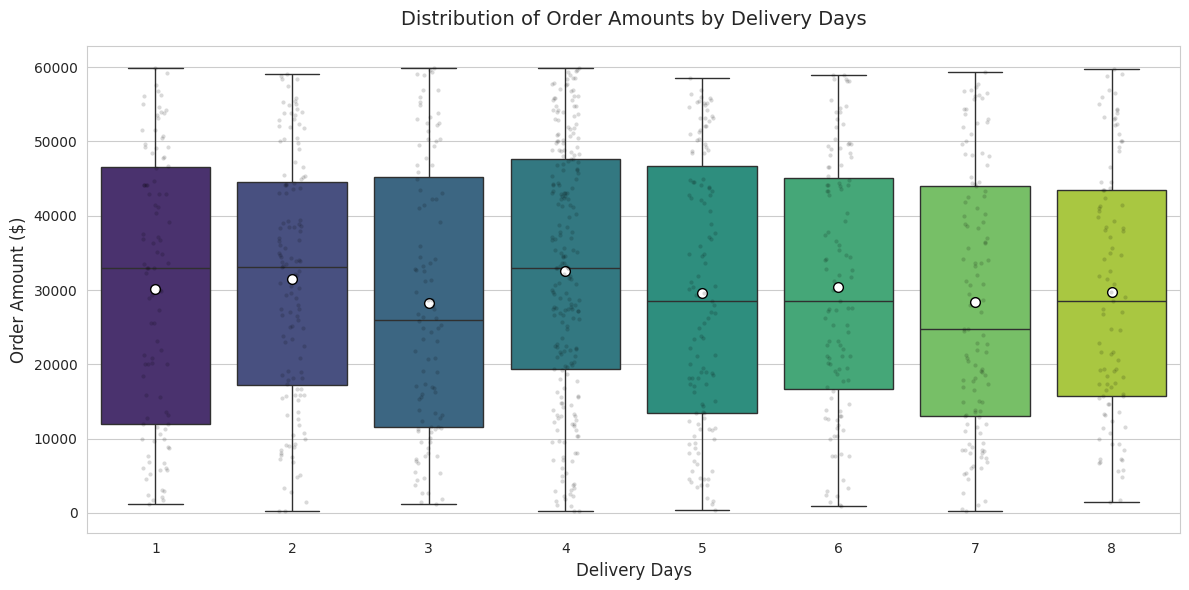

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set a clean visual style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# 2. Create the boxplot with a color palette and mean markers
sns.boxplot(
    data=df,
    x="delivery_days",
    y="order_amount",
    palette="viridis",
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"7"}
)

# 3. Overlay a stripplot to show data density (optional)
sns.stripplot(
    data=df,
    x="delivery_days",
    y="order_amount",
    color="black",
    alpha=0.15,  # Makes dots transparent
    size=3
)

# 4. Clean up labels
plt.title("Distribution of Order Amounts by Delivery Days", fontsize=14, pad=15)
plt.xlabel("Delivery Days", fontsize=12)
plt.ylabel("Order Amount ($)", fontsize=12)

plt.tight_layout()
plt.show()

### Age vs. Spending
**Observations**

* Median and mean order values are nearly identical across all age groups at roughly $30,000.

* Every age bracket shows a full spending range from 0 to 60,000.

* The middle 50% of orders consistently fall between 15,000 and 45,000 regardless of age.

* Data points are densely and evenly distributed across the entire 18–60 age range.

**Insights**

Age Independence: Spending behavior is uniform across demographics, meaning age does not predict order value.

Universal Reach: High-value shoppers are present in every age group, supporting a broad marketing approach.

Priority Shift: Since age is not a differentiator, focus improvements on high-volume delivery windows (like the 4-day mark) where satisfaction typically dips.

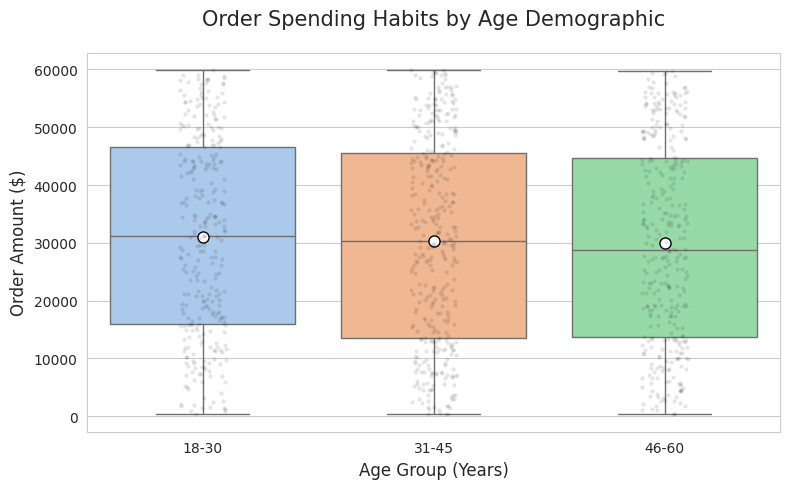

In [85]:
# Create age groups
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 45, 60], labels=['18-30', '31-45', '46-60'])

# 1. Enhance the visual theme
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))

# 2. Create the boxplot with mean markers
# Showmeans helps identify if the average is different from the median
sns.boxplot(
    data=df,
    x='age_group',
    y='order_amount',
    palette="pastel",
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# 3. Add a stripplot to see the actual distribution of the 999 records
sns.stripplot(
    data=df,
    x='age_group',
    y='order_amount',
    color="black",
    alpha=0.1,  # Keep points faint so they don't clutter
    size=3
)

# 4. Final Polish
plt.title("Order Spending Habits by Age Demographic", fontsize=15, pad=20)
plt.xlabel("Age Group (Years)", fontsize=12)
plt.ylabel("Order Amount ($)", fontsize=12)
plt.tight_layout()

plt.show()

### Orders by Month
**Observations**

* Order volume is highest from January to August, consistently

* exceeding 90 orders per month.

* A sharp decline begins in September, reaching a yearly low of 60 orders by November.

* Minor volume dips occur in February and June before quickly recovering.

* The final quarter (Q4) represents the weakest performance period of the year.

**Insights**

Year-End Slump: The significant drop in Q4 suggests a lack of holiday-season momentum or potential stock issues during these months.

Growth Opportunity: Since spending power is consistent across all ages, targeted promotions in September could help mitigate the year-end decline.

Capacity Management: Peak months (Jan–Aug) align with the high-volume 4-day delivery window, which is where customer satisfaction often dips to "average".

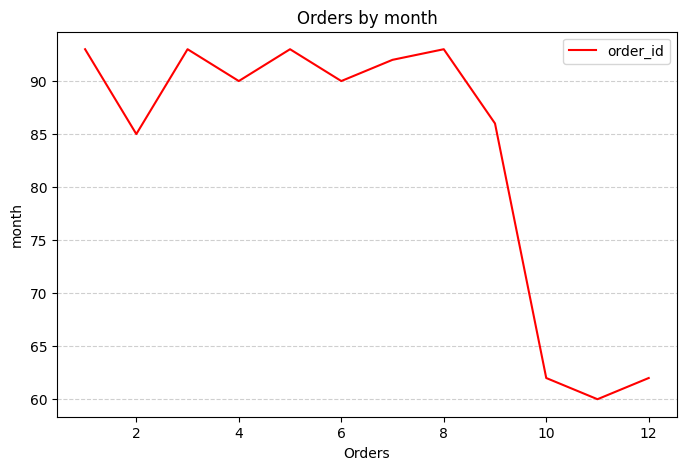

In [61]:
plt.figure(figsize=(8,5))
df.groupby("order_months")["order_id"].count().plot(kind="line",color="red")
plt.xlabel("Orders")
plt.ylabel("month")
plt.title("Orders by month")
plt.legend()
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.show()

### Average Sales by Month
**Observations**

* Peak Sales: Average sales reach their yearly maximum in June (Month 6), peaking at nearly $31,800.

* Deepest Volatility: There is a significant crash in August (Month 8), where sales hit a yearly low of approximately $28,600.

* Mid-Year Recovery: Sales show a sharp, consistent climb from April to June.

* Year-End Bounce: After the August low, sales trend upward through December, recovering to over $31,250.

**Insights**

Inverse Performance: While the number of orders drops significantly in Q4, the average value per sale actually increases during this period. This suggests customers buy fewer, but more expensive, items at year-end.

August Crisis: August is the weakest month for sales value. Combined with a relatively high order volume in that same month, this indicates a period dominated by low-value transactions.

Profitability Window: June is the most profitable month per order. Marketing efforts should be maximized in May to capitalize on this high-value trend.

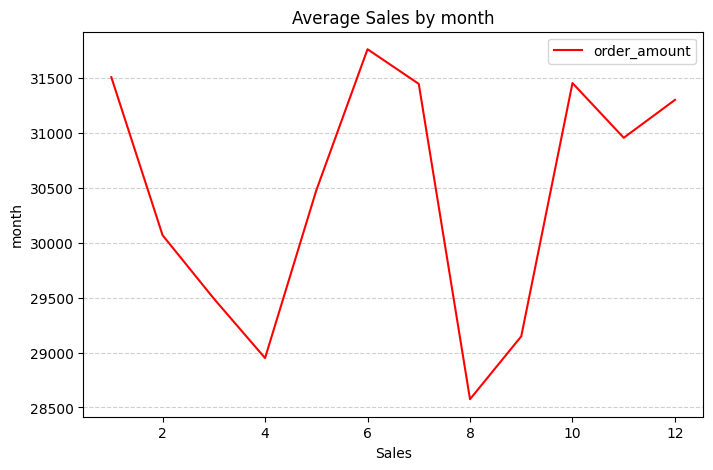

In [62]:
plt.figure(figsize=(8,5))
df.groupby("order_months")["order_amount"].mean().plot(kind="line",color="red")
plt.xlabel("Sales")
plt.ylabel("month")
plt.title("Average Sales by month")
plt.legend()
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.show()

### Average Rating of Orders by Month
**Observations**

* Peak Satisfaction: Average ratings reach a yearly high in September (Month 9) at roughly 3.17.

* Yearly Low: Ratings crash to their lowest point in October (Month 10) at approximately 2.71.

* Mid-Year Trend: There is a steady improvement in customer sentiment from April through July.

* Volatility: The chart shows high fluctuations in the final quarter, with ratings dropping again in December.

**Insights**

Volume Correlation: Ratings peak in September just as order volume begins to drop, suggesting better service quality when the system is less crowded.

High-Value Dissatisfaction: October has low ratings despite an increase in average sale value, meaning customers are unhappier with their more expensive purchases.

Delivery Impact: The "Average" (3-star) rating trend seen in high-volume delivery windows likely keeps ratings stable earlier in the year before the Q4 volatility starts.

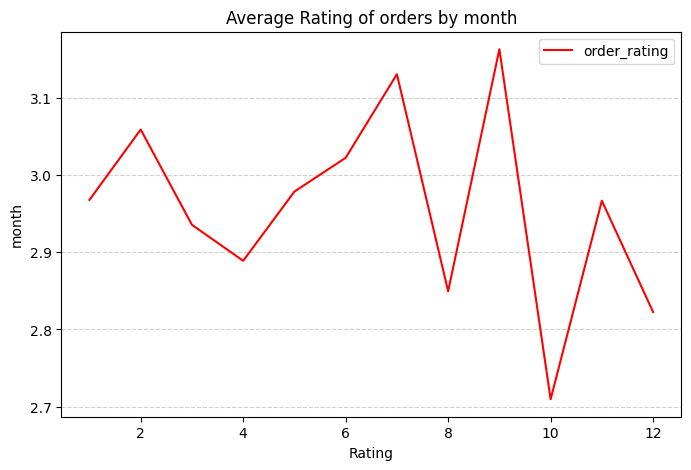

In [63]:
plt.figure(figsize=(8,5))
df.groupby("order_months")["order_rating"].mean().plot(kind="line",color="red")
plt.xlabel("Rating")
plt.ylabel("month")
plt.title("Average Rating of orders by month")
plt.legend()
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.show()

### Sales by Year (2024–2026)
**Observations**

* Sales remained stable and exceeded $30,000 in both 2024 and 2025.

* Total revenue dipped below the $30,000 mark in 2026, showing a clear decline.

* The overall trend shows a gradual year-over-year decrease in sales value.

**Insights**

The 2026 downturn coincides with the significant drop in monthly order volume and satisfaction ratings identified in later months.

Since spending power is consistent across all ages, the decline likely stems from service issues rather than a loss of high-value customers.

Improving logistical performance—specifically addressing the 4-day delivery "average rating trap"—is critical to reversing this three-year slide.

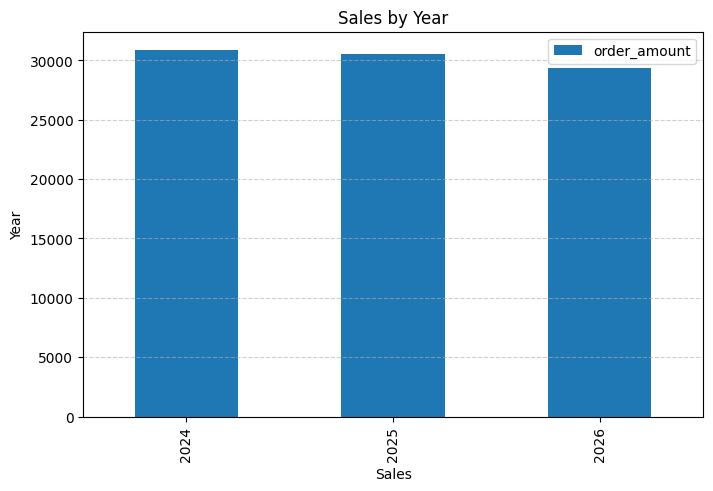

In [64]:
plt.figure(figsize=(8,5))
df.groupby("order_year")["order_amount"].mean().plot(kind="bar")
plt.xlabel("Sales")
plt.ylabel("Year")
plt.title("Sales by Year")
plt.legend()
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.show()
